# Classification Modeling on Walmart Weekly Sales

This notebook converts `Weekly_Sales` into classification labels (e.g., Low/Medium/High) and trains 10+ classification methods (including at least 3 deep neural networks).

Outputs: results CSV, hyperparameters CSV, figures (confusion matrices, performance comparison).

In [1]:
# 1) Imports and settings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, classification_report, confusion_matrix

In [2]:
# Run flags: set RUN_DNNS=False to skip deep learning sections when TF is unavailable
# This cell will auto-enable DNNs when running inside Google Colab (GPU runtime).
import sys, os
# Detect Colab environment
try:
    import google.colab  # type: ignore
    IN_COLAB = True
except Exception:
    IN_COLAB = False

# Default: do not run DNNs locally unless explicitly allowed
RUN_DNNS = False
if IN_COLAB:
    RUN_DNNS = True

# Random seeds for reproducibility
SEED = 42
import numpy as _np
import random as _random
_np.random.seed(SEED)
_random.seed(SEED)
# scikit-learn seed will be passed to relevant functions where applicable
# When RUN_DNNS is True we set TF seeds inside the DNN cell before training


In [3]:
# 2) Load Walmart dataset
df = pd.read_csv('walmart-sales-dataset-of-45stores.csv')
print(f'Dataset shape: {df.shape}')
print('Columns:', list(df.columns))
df.head()

Dataset shape: (6435, 8)
Columns: ['Store', 'Date', 'Weekly_Sales', 'Holiday_Flag', 'Temperature', 'Fuel_Price', 'CPI', 'Unemployment']


,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
0,1,05-02-2010,1643690.90,0,42.31,2.572,211.096358,8.106
1,1,12-02-2010,1641957.44,1,38.51,2.548,211.242170,8.106
2,1,19-02-2010,1611968.17,0,39.93,2.514,211.289143,8.106
3,1,26-02-2010,1409727.59,0,46.63,2.561,211.319643,8.106
4,1,05-03-2010,1554806.68,0,46.50,2.625,211.350143,8.106


## How to run DNNs in Google Colab

To run the deep neural networks (recommended):

1. Open this notebook in Google Colab: https://colab.research.google.com → Upload the notebook file (`Classification_Walmart.ipynb`).
2. Runtime → Change runtime type → select GPU and click Save.
3. (Optional) Mount your Google Drive if you want to persist models/outputs across sessions:

```python
from google.colab import drive
drive.mount('/content/drive')
# then set an output path like '/content/drive/MyDrive/walmart_classif_outputs'
```

4. Run menu → Run all. The notebook auto-detects Colab and will enable DNN cells (RUN_DNNS=True). Outputs (CSV and PNG files) will be created in the working directory; if you mounted Drive, save them to Drive to keep them.

Notes:
- The notebook will run the classical models on CPU first, then the 3 DNNs on GPU.
- Epochs are set to reasonable defaults; you can reduce epochs for quicker runs.


In [4]:
# 3) Feature selection and label creation
# We'll create a 3-class target (Low/Medium/High) using tertiles (quantiles).
df = df.copy()
if 'Weekly_Sales' not in df.columns:
    raise RuntimeError('Weekly_Sales column not found in dataset')
# Create class labels based on quantiles
quantiles = df['Weekly_Sales'].quantile([0.33, 0.66]).values
q1, q2 = quantiles[0], quantiles[1]
def sales_to_class(x):
    if x <= q1:
        return 0  # Low
    elif x <= q2:
        return 1  # Medium
    else:
        return 2  # High
df['sales_class'] = df['Weekly_Sales'].apply(sales_to_class)
print('Class distribution:')
print(df['sales_class'].value_counts(normalize=True) * 100)
df[['Weekly_Sales','sales_class']].head()

Class distribution:
sales_class
2    34.001554
0    33.006993
1    32.991453
Name: proportion, dtype: float64


,Weekly_Sales,sales_class
0,1643690.90,2
1,1641957.44,2
2,1611968.17,2
3,1409727.59,2
4,1554806.68,2


In [5]:
# 4) Train/Validation/Test split (60/20/20) stratified by class
X = df.drop(columns=['sales_class'])
y = df['sales_class']
# First split off test set (20%)
X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
# Then split remaining into train (60%) and val (20%) => val = 0.25 of temp
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.25, random_state=42, stratify=y_temp)
print('Splits ->', len(X_train), len(X_val), len(X_test))

Splits -> 3861 1287 1287


In [6]:
# 5) Identify numeric and categorical features
num_cols = X_train.select_dtypes(include=['int64','float64']).columns.tolist()
cat_cols = X_train.select_dtypes(include=['object','category']).columns.tolist()
# Drop target-like columns and identifiers if present
for col in ['Date','Weekly_Sales']:
    if col in num_cols:
        num_cols.remove(col)
# Ensure we keep informative numeric features only
print('Numeric columns:', num_cols)
print('Categorical columns:', cat_cols)

# Build preprocessing pipeline
numeric_transformer = Pipeline(steps=[('scaler', StandardScaler())])
# Ensure OneHotEncoder returns dense arrays so downstream estimators that require dense input (e.g., GaussianNB) work correctly.
# Use sparse_output when available, otherwise fall back to sparse=False for older sklearn versions.
try:
    categorical_transformer = Pipeline(steps=[('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))])
except TypeError:
    categorical_transformer = Pipeline(steps=[('onehot', OneHotEncoder(handle_unknown='ignore', sparse=False))])
preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer, num_cols),
    ('cat', categorical_transformer, cat_cols)
])

Numeric columns: ['Store', 'Holiday_Flag', 'Temperature', 'Fuel_Price', 'CPI', 'Unemployment']
Categorical columns: ['Date']


In [7]:
# 6) Define models and hyperparameters
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier, ExtraTreesClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
# XGBoost optional: try import; fallback if not installed
try:
    from xgboost import XGBClassifier
    xgb_available = True
except Exception:
    xgb_available = False

models = {
    'LogisticRegression': LogisticRegression(max_iter=1000, random_state=42),
    'RandomForest': RandomForestClassifier(n_estimators=200, random_state=42),
    'ExtraTrees': ExtraTreesClassifier(n_estimators=200, random_state=42),
    'GradientBoosting': GradientBoostingClassifier(random_state=42),
    'AdaBoost': AdaBoostClassifier(random_state=42),
    'KNN': KNeighborsClassifier(n_neighbors=5),
    'LinearSVC': LinearSVC(max_iter=5000, random_state=42),
    'NaiveBayes': GaussianNB(),
    'DecisionTree': DecisionTreeClassifier(random_state=42)
}
if xgb_available:
    models['XGBoost'] = XGBClassifier(use_label_encoder=False, eval_metric='mlogloss', random_state=42)

# Hyperparameters dictionary (for logging) -- simple defaults used here
hyperparams = {name: getattr(m, 'get_params', lambda: {})() for name, m in models.items()}

print('Models defined:', list(models.keys()))

Models defined: ['LogisticRegression', 'RandomForest', 'ExtraTrees', 'GradientBoosting', 'AdaBoost', 'KNN', 'LinearSVC', 'NaiveBayes', 'DecisionTree', 'XGBoost']


In [8]:
# 7) Train classical models and evaluate on validation set
from sklearn.base import TransformerMixin, BaseEstimator

class DenseTransformer(TransformerMixin, BaseEstimator):
    def fit(self, X, y=None):
        return self
    def transform(self, X):
        # convert sparse matrices to dense arrays for estimators that require dense input
        if hasattr(X, 'toarray'):
            return X.toarray()
        return np.asarray(X)

results = []
for name, model in models.items():
    # Some estimators (e.g., GaussianNB) require dense input; insert a conversion step when needed
    if isinstance(model, GaussianNB):
        pipe = Pipeline(steps=[('preprocessor', preprocessor), ('to_dense', DenseTransformer()), ('clf', model)])
    else:
        pipe = Pipeline(steps=[('preprocessor', preprocessor), ('clf', model)])
    print(f'Training {name}...')
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_val)
    acc = accuracy_score(y_val, y_pred)
    prec, rec, f1, _ = precision_recall_fscore_support(y_val, y_pred, average='weighted')
    results.append({'Method': name, 'Accuracy': acc, 'Precision': prec, 'Recall': rec, 'F1': f1})

results_df = pd.DataFrame(results).sort_values('F1', ascending=False)
print('\nValidation results:')
print(results_df)
results_df.to_csv('classification_results_classical_validation.csv', index=False)
print('Saved classical validation results CSV')

Training LogisticRegression...
Training RandomForest...


Training ExtraTrees...


Training GradientBoosting...


Training AdaBoost...
Training KNN...
Training LinearSVC...


Training NaiveBayes...
Training DecisionTree...
Training XGBoost...



Validation results:
               Method  Accuracy  Precision    Recall        F1
9             XGBoost  0.933955   0.933887  0.933955  0.933910
8        DecisionTree  0.915307   0.915378  0.915307  0.915290
3    GradientBoosting  0.913753   0.914236  0.913753  0.913920
1        RandomForest  0.879565   0.880918  0.879565  0.879236
2          ExtraTrees  0.815074   0.815359  0.815074  0.815118
5                 KNN  0.553225   0.559476  0.553225  0.547205
4            AdaBoost  0.533800   0.531233  0.533800  0.514692
6           LinearSVC  0.508159   0.507517  0.508159  0.502521
0  LogisticRegression  0.491064   0.490347  0.491064  0.487513
7          NaiveBayes  0.299922   0.300522  0.299922  0.300180
Saved classical validation results CSV


In [9]:
# 8) Deep learning models (Keras) - three DNNs: MLP, 1D-CNN, Deeper MLP
if RUN_DNNS:
    import tensorflow as tf
    from tensorflow import keras
    from tensorflow.keras import layers

    # Prepare preprocessed numeric array for Keras: fit preprocessor on training set and transform train/val/test
    preprocessor.fit(X_train)
    X_train_proc = preprocessor.transform(X_train)
    X_val_proc = preprocessor.transform(X_val)
    X_test_proc = preprocessor.transform(X_test)

    # Convert to dense arrays (sparse from OneHotEncoder)
    if hasattr(X_train_proc, 'toarray'):
        X_train_arr = X_train_proc.toarray()
        X_val_arr = X_val_proc.toarray()
        X_test_arr = X_test_proc.toarray()
    else:
        X_train_arr = X_train_proc
        X_val_arr = X_val_proc
        X_test_arr = X_test_proc

    input_dim = X_train_arr.shape[1]
    print('Input dim for DNNs:', input_dim)

    # Helper to compile and train a model
    def train_keras_model(model, name, epochs=30, batch_size=32):
        model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
        print(f'Training {name}...')
        hist = model.fit(X_train_arr, y_train, validation_data=(X_val_arr, y_val), epochs=epochs, batch_size=batch_size, verbose=0)
        y_pred = np.argmax(model.predict(X_val_arr), axis=1)
        acc = accuracy_score(y_val, y_pred)
        prec, rec, f1, _ = precision_recall_fscore_support(y_val, y_pred, average='weighted')
        return {'Method': name, 'Accuracy': acc, 'Precision': prec, 'Recall': rec, 'F1': f1}, hist

    # DNN 1: Simple MLP
    mlp = keras.Sequential([layers.Input(shape=(input_dim,)), layers.Dense(256, activation='relu'), layers.Dropout(0.2), layers.Dense(128, activation='relu'), layers.Dropout(0.2), layers.Dense(3, activation='softmax')])
    res_mlp, hist_mlp = train_keras_model(mlp, 'DNN_MLP')

    # DNN 2: 1D-CNN (treat features as a 1D sequence)
    X_train_cnn = X_train_arr.reshape((-1, input_dim, 1))
    X_val_cnn = X_val_arr.reshape((-1, input_dim, 1))
    X_test_cnn = X_test_arr.reshape((-1, input_dim, 1))
    cnn = keras.Sequential([layers.Input(shape=(input_dim,1)), layers.Conv1D(64, kernel_size=3, activation='relu'), layers.MaxPooling1D(2), layers.Conv1D(32, kernel_size=3, activation='relu'), layers.GlobalMaxPooling1D(), layers.Dense(64, activation='relu'), layers.Dense(3, activation='softmax')])
    res_cnn, hist_cnn = train_keras_model(cnn, 'DNN_CNN')

    # DNN 3: Deeper MLP
    deep_mlp = keras.Sequential([layers.Input(shape=(input_dim,)), layers.Dense(512, activation='relu'), layers.Dropout(0.3), layers.Dense(256, activation='relu'), layers.Dropout(0.3), layers.Dense(128, activation='relu'), layers.Dense(3, activation='softmax')])
    res_deep_mlp, hist_deep_mlp = train_keras_model(deep_mlp, 'DNN_DeepMLP')

    # Append DNN results to results_df
    dnn_results = pd.DataFrame([res_mlp, res_cnn, res_deep_mlp])
    results_df = pd.concat([results_df, dnn_results], ignore_index=True).sort_values('F1', ascending=False)
    print('\nCombined validation results (classical + DNNs):')
    print(results_df)
    results_df.to_csv('classification_results_all_validation.csv', index=False)
    print('Saved combined validation results CSV')


In [10]:
# 9) Final evaluation on test set using best model (by F1 on validation)
best_method = results_df.iloc[0]['Method']
print('Best method on validation:', best_method)

if best_method.startswith('DNN'):
    # map name to model object
    dnn_map = {'DNN_MLP': mlp, 'DNN_CNN': cnn, 'DNN_DeepMLP': deep_mlp}
    model_to_eval = dnn_map[best_method]
    if best_method == 'DNN_CNN':
        y_pred_test = np.argmax(model_to_eval.predict(X_test_cnn), axis=1)
    else:
        y_pred_test = np.argmax(model_to_eval.predict(X_test_arr), axis=1)
else:
    # re-create pipeline for classical model
    clf = models[best_method]
    pipe = Pipeline(steps=[('preprocessor', preprocessor), ('clf', clf)])
    pipe.fit(X_train, y_train)
    y_pred_test = pipe.predict(X_test)

acc_test = accuracy_score(y_test, y_pred_test)
prec_test, rec_test, f1_test, _ = precision_recall_fscore_support(y_test, y_pred_test, average='weighted')
print('Test metrics ->', {'Accuracy': acc_test, 'Precision': prec_test, 'Recall': rec_test, 'F1': f1_test})
test_summary = pd.DataFrame([{'Method': best_method,'Accuracy': acc_test,'Precision': prec_test,'Recall': rec_test,'F1': f1_test}])
test_summary.to_csv('classification_best_model_test_results.csv', index=False)
print('Saved test results CSV')

Best method on validation: XGBoost


Test metrics -> {'Accuracy': 0.9355089355089355, 'Precision': 0.9352480359261774, 'Recall': 0.9355089355089355, 'F1': 0.9353418467776401}
Saved test results CSV


In [11]:
# 10) Save hyperparameters used (simple logging)
# For DNNs we save layer counts and basic config
hp_rows = []
for name in models.keys():
    hp_rows.append({'Method': name, 'Hyperparams': str(hyperparams.get(name, {}))})
hp_rows.append({'Method': 'DNN_MLP', 'Hyperparams': 'layers=[256,128], dropout=0.2, epochs=30'})
hp_rows.append({'Method': 'DNN_CNN', 'Hyperparams': 'Conv1D(64,3)->Conv1D(32,3), epochs=30'})
hp_rows.append({'Method': 'DNN_DeepMLP', 'Hyperparams': 'layers=[512,256,128], dropout=0.3, epochs=30'})
hp_df = pd.DataFrame(hp_rows)
hp_df.to_csv('classification_hyperparameters.csv', index=False)
print('Saved hyperparameters CSV')

Saved hyperparameters CSV


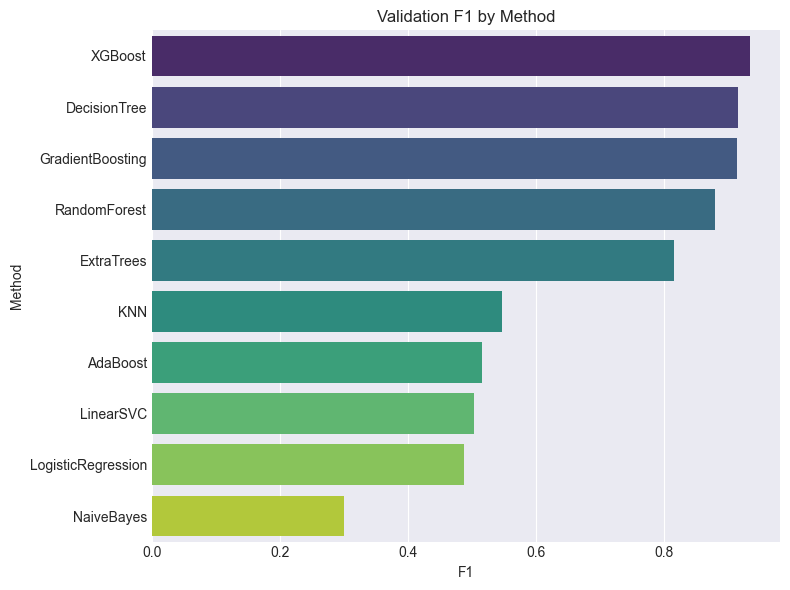

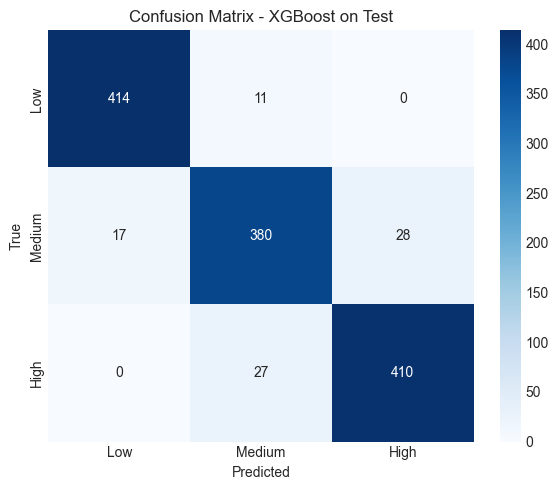

In [12]:
# 11) Figures: performance bar chart and confusion matrix for best model
plt.figure(figsize=(8,6))
sns.barplot(data=results_df.sort_values('F1', ascending=False), x='F1', y='Method', palette='viridis')
plt.title('Validation F1 by Method')
plt.tight_layout()
plt.savefig('validation_f1_by_method.png', dpi=300, bbox_inches='tight')
plt.show()

# Confusion matrix for best model on test set
cm = confusion_matrix(y_test, y_pred_test)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Low','Medium','High'], yticklabels=['Low','Medium','High'])
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title(f'Confusion Matrix - {best_method} on Test')
plt.tight_layout()
plt.savefig('confusion_matrix_best_test.png', dpi=300, bbox_inches='tight')
plt.show()

## Discussion of Results

This section summarizes findings, strengths/weaknesses of methods, and recommendations. Use the saved CSVs and figures to write a short interpretation of model performance and business implications. Consider calibration, class imbalance handling, and feature importance (for tree-based models).